In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\VIKASH KUMAR\Downloads\DATA_DUMP\archive (5)\Admission_Predict_Ver1.1.csv")

In [4]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop(columns=["Serial No."], inplace=True)

In [8]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [11]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
x_train

array([[0.4       , 0.42857143, 0.5       , ..., 0.57142857, 0.50320513,
        0.        ],
       [0.56      , 0.64285714, 0.        , ..., 0.57142857, 0.55769231,
        1.        ],
       [0.2       , 0.32142857, 0.5       , ..., 0.28571429, 0.34615385,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.74038462,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.77884615,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.32051282,
        0.        ]], shape=(400, 7))

In [13]:
y_train

array([0.7 , 0.67, 0.59, 0.36, 0.78, 0.44, 0.71, 0.71, 0.66, 0.64, 0.47,
       0.84, 0.94, 0.76, 0.76, 0.71, 0.58, 0.63, 0.46, 0.77, 0.86, 0.49,
       0.52, 0.92, 0.71, 0.58, 0.96, 0.79, 0.5 , 0.86, 0.51, 0.44, 0.93,
       0.96, 0.95, 0.81, 0.89, 0.71, 0.38, 0.61, 0.78, 0.87, 0.69, 0.56,
       0.69, 0.73, 0.73, 0.42, 0.57, 0.95, 0.62, 0.47, 0.9 , 0.48, 0.85,
       0.77, 0.7 , 0.86, 0.9 , 0.56, 0.63, 0.73, 0.34, 0.8 , 0.71, 0.71,
       0.78, 0.92, 0.69, 0.83, 0.44, 0.74, 0.49, 0.84, 0.89, 0.89, 0.53,
       0.78, 0.84, 0.38, 0.72, 0.42, 0.56, 0.64, 0.72, 0.58, 0.42, 0.94,
       0.78, 0.46, 0.67, 0.85, 0.84, 0.66, 0.65, 0.77, 0.84, 0.73, 0.73,
       0.58, 0.79, 0.84, 0.59, 0.64, 0.64, 0.62, 0.77, 0.57, 0.87, 0.72,
       0.87, 0.61, 0.91, 0.81, 0.61, 0.8 , 0.69, 0.56, 0.62, 0.45, 0.62,
       0.66, 0.69, 0.92, 0.62, 0.69, 0.78, 0.63, 0.83, 0.71, 0.91, 0.94,
       0.75, 0.49, 0.79, 0.52, 0.93, 0.61, 0.59, 0.68, 0.64, 0.72, 0.63,
       0.93, 0.82, 0.87, 0.81, 0.52, 0.71, 0.9 , 0.

In [23]:
from keras.layers import Dense, Input
from keras import Sequential

In [34]:
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1, activation="linear") # for regression
])
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(loss = 'mean_squared_error', optimizer = 'adam')
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=1)

Epoch 1/10


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6787 - val_loss: 0.2469
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0771 - val_loss: 0.0123
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0283 - val_loss: 0.0322
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0163 - val_loss: 0.0080
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0092 - val_loss: 0.0099
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0083 - val_loss: 0.0066
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064 - val_loss: 0.0068
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0060 - val_loss: 0.0057
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0050 - val_loss: 0.0050


In [36]:
y_pred = model.predict(x_test)
y_pred 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[0.6507628 ],
       [0.679242  ],
       [1.0748864 ],
       [0.7016344 ],
       [0.8176278 ],
       [0.6644601 ],
       [0.7081386 ],
       [0.6964555 ],
       [0.76336753],
       [0.64308256],
       [0.7229781 ],
       [0.6027176 ],
       [0.75613207],
       [0.86636704],
       [0.7475361 ],
       [0.8940018 ],
       [0.59790826],
       [0.7903352 ],
       [0.91707146],
       [0.67243385],
       [0.6844254 ],
       [0.8250344 ],
       [0.83645236],
       [0.6306057 ],
       [0.848161  ],
       [0.55283844],
       [0.96222997],
       [0.63051033],
       [0.8578526 ],
       [0.6886817 ],
       [0.60750014],
       [0.801074  ],
       [0.5850825 ],
       [0.91259223],
       [0.4921442 ],
       [0.7910625 ],
       [0.6940551 ],
       [0.63109756],
       [0.67482   ],
       [0.90617937],
       [0.5140389 ],
       [0.65440506],
       [0.76965237],
       [1.0098288 ],
       [0.7399659 ],
       [0.43972772],
       [0.6562746 ],
       [0.615

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.004953950086635236
R^2 Score: 0.7434648600986362


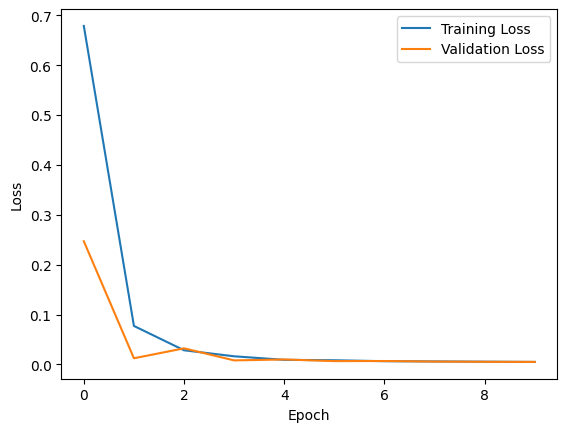

In [38]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()